In [1]:
!pip install -q kagglehub

In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
path = kagglehub.dataset_download(
    "kritikseth/fruit-and-vegetable-image-recognition"
)

print("Dataset downloaded successfully.")
print("Dataset path:")
print(path)

100%|██████████| 1.98G/1.98G [00:26<00:00, 81.1MB/s]

Extracting files...


Dataset downloaded successfully.
Dataset path:
/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


In [4]:
print("Main folders/files:")

for item in os.listdir(path):
    print(item)

Main folders/files:
train
test
validation


In [5]:
train_path = os.path.join(path, "train")
validation_path = os.path.join(path, "validation")
test_path = os.path.join(path, "test")

print("Train exists:", os.path.exists(train_path))
print("Validation exists:", os.path.exists(validation_path))
print("Test exists:", os.path.exists(test_path))

Train exists: True
Validation exists: True
Test exists: True


In [6]:
original_classes = sorted(
    [
        folder
        for folder in os.listdir(train_path)
        if os.path.isdir(os.path.join(train_path, folder))
    ]
)

print("Number of original classes:", len(original_classes))

print("\nClasses:")

for cls in original_classes:
    print(cls)

Number of original classes: 36

Classes:
apple
banana
beetroot
bell pepper
cabbage
capsicum
carrot
cauliflower
chilli pepper
corn
cucumber
eggplant
garlic
ginger
grapes
jalepeno
kiwi
lemon
lettuce
mango
onion
orange
paprika
pear
peas
pineapple
pomegranate
potato
raddish
soy beans
spinach
sweetcorn
sweetpotato
tomato
turnip
watermelon


In [7]:
fruit_classes = [
    "apple",
    "banana",
    "pear",
    "grapes",
    "orange",
    "kiwi",
    "watermelon",
    "pomegranate",
    "pineapple",
    "mango"
]

In [8]:
fruit_classes = [x.lower() for x in fruit_classes]

print(fruit_classes)

['apple', 'banana', 'pear', 'grapes', 'orange', 'kiwi', 'watermelon', 'pomegranate', 'pineapple', 'mango']


In [9]:
vegetable_classes = [
    cls
    for cls in original_classes
    if cls.lower() not in fruit_classes
]

print("FRUITS")
print(fruit_classes)

print("\nVEGETABLES")
print(vegetable_classes)

FRUITS
['apple', 'banana', 'pear', 'grapes', 'orange', 'kiwi', 'watermelon', 'pomegranate', 'pineapple', 'mango']

VEGETABLES
['beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'jalepeno', 'lemon', 'lettuce', 'onion', 'paprika', 'peas', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip']


In [10]:
dataset_lower = [x.lower() for x in original_classes]

for fruit in fruit_classes:

    if fruit in dataset_lower:
        print(f"{fruit}: Found")
    else:
        print(f"{fruit}: NOT FOUND")

apple: Found
banana: Found
pear: Found
grapes: Found
orange: Found
kiwi: Found
watermelon: Found
pomegranate: Found
pineapple: Found
mango: Found


In [11]:
class_counts = []

for cls in original_classes:

    class_folder = os.path.join(
        train_path,
        cls
    )

    images = [
        f for f in os.listdir(class_folder)
        if os.path.isfile(
            os.path.join(class_folder, f)
        )
    ]

    class_counts.append(
        [cls, len(images)]
    )

class_count_df = pd.DataFrame(
    class_counts,
    columns=[
        "Class",
        "Number_of_Training_Images"
    ]
)

display(class_count_df)

,Class,Number_of_Training_Images
0,apple,68
1,banana,75
2,beetroot,88
3,bell pepper,90
4,cabbage,92
5,capsicum,89
6,carrot,82
7,cauliflower,79
8,chilli pepper,87
9,corn,87


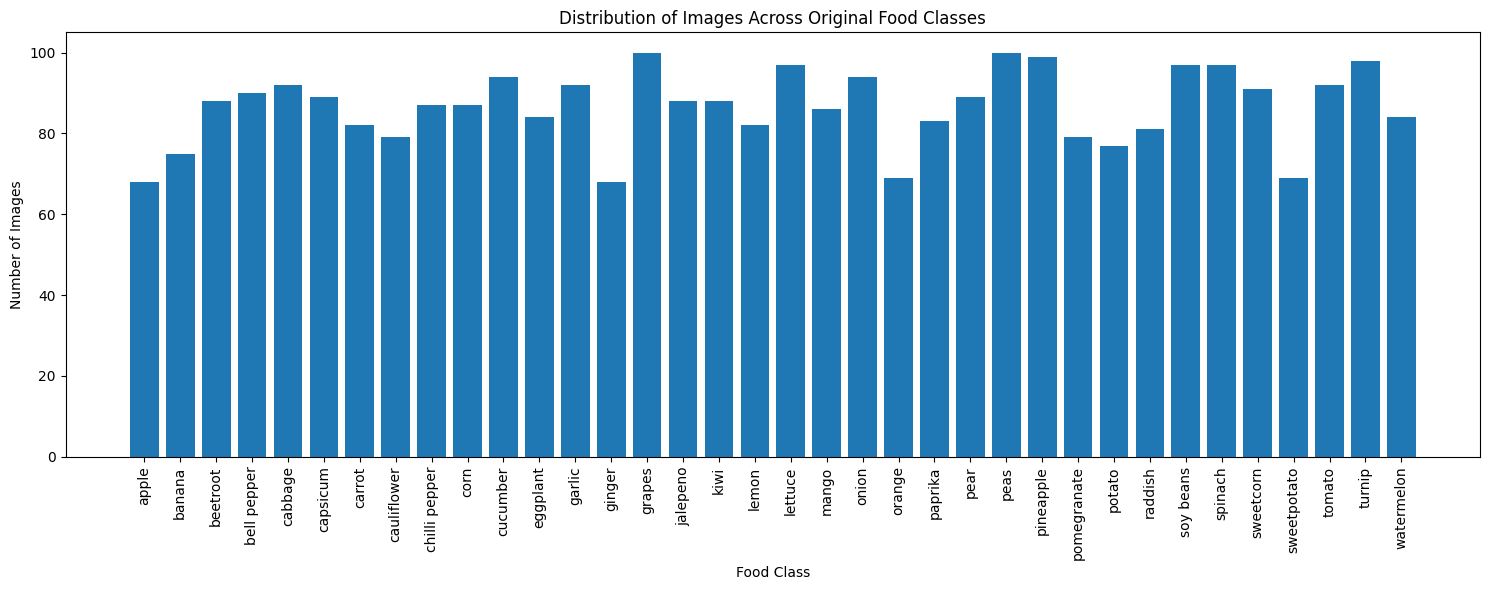

In [12]:
plt.figure(figsize=(15, 6))

plt.bar(
    class_count_df["Class"],
    class_count_df["Number_of_Training_Images"]
)

plt.title(
    "Distribution of Images Across Original Food Classes"
)

plt.xlabel("Food Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [13]:
binary_base = "/content/binary_dataset"

if os.path.exists(binary_base):
    shutil.rmtree(binary_base)

print("Old binary dataset removed if it existed.")

Old binary dataset removed if it existed.


In [14]:
splits = [
    "train",
    "validation",
    "test"
]

categories = [
    "fruit",
    "vegetable"
]

for split in splits:

    for category in categories:

        folder_path = os.path.join(
            binary_base,
            split,
            category
        )

        os.makedirs(
            folder_path,
            exist_ok=True
        )

print("Binary dataset folders created.")

Binary dataset folders created.


In [15]:
def create_binary_dataset(
    source_folder,
    destination_folder
):

    total_copied = 0

    for class_name in os.listdir(source_folder):

        class_path = os.path.join(
            source_folder,
            class_name
        )

        if not os.path.isdir(class_path):
            continue

        if class_name.lower() in fruit_classes:

            category = "fruit"

        else:

            category = "vegetable"

        destination_category = os.path.join(
            destination_folder,
            category
        )

        for image_name in os.listdir(class_path):

            source_image = os.path.join(
                class_path,
                image_name
            )

            if not os.path.isfile(source_image):
                continue

            # Prevent duplicate filenames
            new_name = (
                class_name
                .replace(" ", "_")
                .replace("/", "_")
                + "_"
                + image_name
            )

            destination_image = os.path.join(
                destination_category,
                new_name
            )

            shutil.copy2(
                source_image,
                destination_image
            )

            total_copied += 1

    return total_copied

In [16]:
train_count = create_binary_dataset(
    train_path,
    os.path.join(
        binary_base,
        "train"
    )
)

print(
    "Training images copied:",
    train_count
)

Training images copied: 3115


In [17]:
validation_count = create_binary_dataset(
    validation_path,
    os.path.join(
        binary_base,
        "validation"
    )
)

print(
    "Validation images copied:",
    validation_count
)

Validation images copied: 351


In [18]:
test_count = create_binary_dataset(
    test_path,
    os.path.join(
        binary_base,
        "test"
    )
)

print(
    "Test images copied:",
    test_count
)

Test images copied: 359


In [19]:
for split in splits:

    print("\n", split.upper())

    for category in categories:

        folder = os.path.join(
            binary_base,
            split,
            category
        )

        count = len([
            f for f in os.listdir(folder)
            if os.path.isfile(
                os.path.join(folder, f)
            )
        ])

        print(
            category,
            ":",
            count
        )


 TRAIN
fruit : 837
vegetable : 2278

 VALIDATION
fruit : 97
vegetable : 254

 TEST
fruit : 99
vegetable : 260


In [20]:
binary_counts = []

for split in splits:

    for category in categories:

        folder = os.path.join(
            binary_base,
            split,
            category
        )

        count = len(
            os.listdir(folder)
        )

        binary_counts.append(
            [split, category, count]
        )

binary_df = pd.DataFrame(
    binary_counts,
    columns=[
        "Dataset",
        "Category",
        "Images"
    ]
)

display(binary_df)

,Dataset,Category,Images
0,train,fruit,837
1,train,vegetable,2278
2,validation,fruit,97
3,validation,vegetable,254
4,test,fruit,99
5,test,vegetable,260


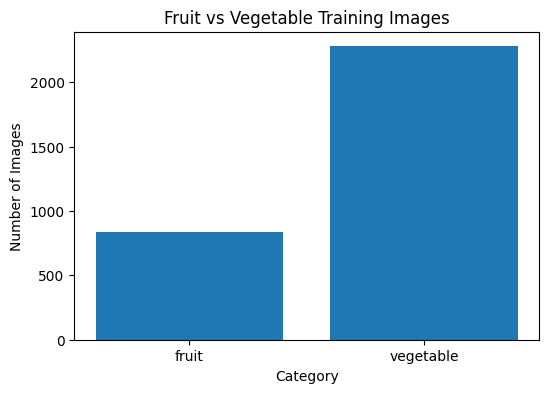

In [21]:
train_distribution = binary_df[
    binary_df["Dataset"] == "train"
]

plt.figure(figsize=(6, 4))

plt.bar(
    train_distribution["Category"],
    train_distribution["Images"]
)

plt.title(
    "Fruit vs Vegetable Training Images"
)

plt.xlabel("Category")
plt.ylabel("Number of Images")

plt.show()

In [22]:
fruit_folder = os.path.join(
    binary_base,
    "train",
    "fruit"
)

vegetable_folder = os.path.join(
    binary_base,
    "train",
    "vegetable"
)

In [23]:
fruit_images = random.sample(
    os.listdir(fruit_folder),
    min(4, len(os.listdir(fruit_folder)))
)

vegetable_images = random.sample(
    os.listdir(vegetable_folder),
    min(4, len(os.listdir(vegetable_folder)))
)

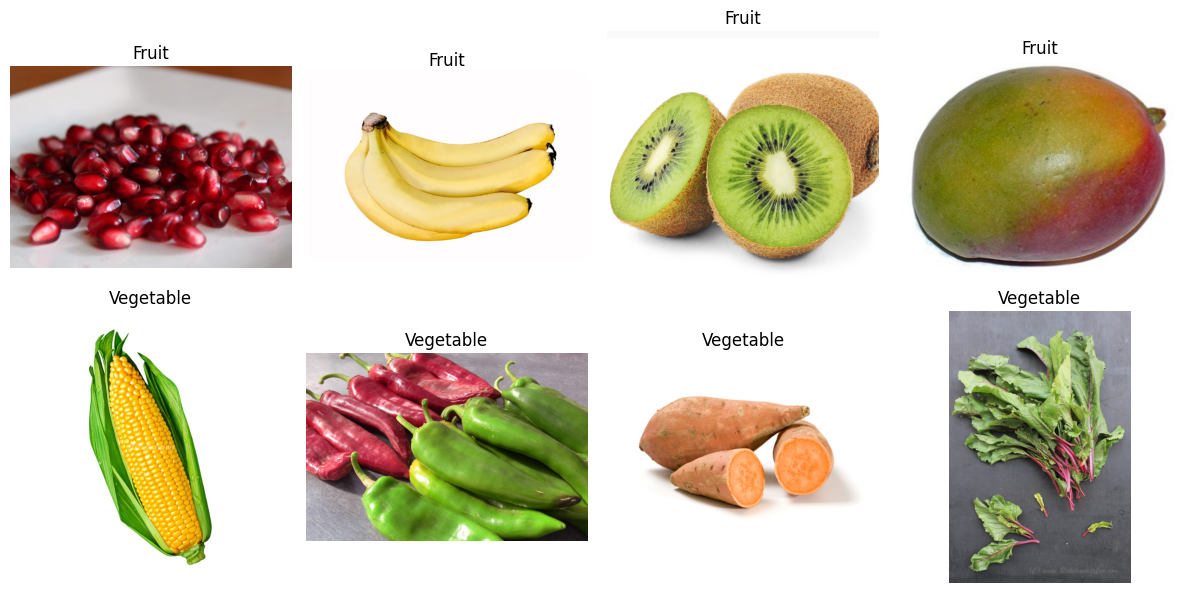

In [24]:
plt.figure(
    figsize=(12, 6)
)

for i, image_name in enumerate(fruit_images):

    img = load_img(
        os.path.join(
            fruit_folder,
            image_name
        )
    )

    plt.subplot(
        2,
        4,
        i + 1
    )

    plt.imshow(img)

    plt.title("Fruit")

    plt.axis("off")


for i, image_name in enumerate(vegetable_images):

    img = load_img(
        os.path.join(
            vegetable_folder,
            image_name
        )
    )

    plt.subplot(
        2,
        4,
        i + 5
    )

    plt.imshow(img)

    plt.title("Vegetable")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [25]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [26]:
train_datagen = ImageDataGenerator(

    rescale=1.0 / 255,

    rotation_range=20,

    width_shift_range=0.1,

    height_shift_range=0.1,

    shear_range=0.1,

    zoom_range=0.15,

    horizontal_flip=True,

    fill_mode="nearest"
)

In [27]:
validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [28]:
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [29]:
rescale=1./255

In [30]:
train_generator = train_datagen.flow_from_directory(

    os.path.join(
        binary_base,
        "train"
    ),

    target_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=True
)

Found 3115 images belonging to 2 classes.


In [31]:
validation_generator = validation_datagen.flow_from_directory(

    os.path.join(
        binary_base,
        "validation"
    ),

    target_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=False
)

Found 351 images belonging to 2 classes.


In [32]:
test_generator = test_datagen.flow_from_directory(

    os.path.join(
        binary_base,
        "test"
    ),

    target_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=False
)

Found 359 images belonging to 2 classes.


In [33]:
print(
    "Class Mapping:",
    train_generator.class_indices
)

Class Mapping: {'fruit': 0, 'vegetable': 1}


In [34]:
images, labels = next(
    train_generator
)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [35]:
model = Sequential([

    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),


    Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),


    Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),


    Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),


    Flatten(),


    Dense(
        128,
        activation="relu"
    ),


    Dropout(0.5),


    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [38]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)

In [39]:
print(
    "Train samples:",
    train_generator.samples
)

print(
    "Validation samples:",
    validation_generator.samples
)

print(
    "Test samples:",
    test_generator.samples
)

print(
    "Classes:",
    train_generator.class_indices
)

Train samples: 3115
Validation samples: 351
Test samples: 359
Classes: {'fruit': 0, 'vegetable': 1}


In [40]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=15,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/15
 7/98 ━━━━━━━━━━━━━━━━━━━━ 4:10 3s/step - accuracy: 0.6894 - loss: 0.6517

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.7307 - loss: 0.5941 - val_accuracy: 0.7236 - val_loss: 0.5570
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.7294 - loss: 0.5746 - val_accuracy: 0.7236 - val_loss: 0.5487
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.7313 - loss: 0.5620 - val_accuracy: 0.7236 - val_loss: 0.5448
Epoch 4/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.7310 - loss: 0.5413 - val_accuracy: 0.7236 - val_loss: 0.5167
Epoch 5/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.7313 - loss: 0.5326 - val_accuracy: 0.7379 - val_loss: 0.4908
Epoch 6/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.7352 - loss: 0.5342 - val_accuracy: 0.7407 - val_loss: 0.4742
Epoch 7/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.7470 - loss: 0.5223 - val_accuracy: 0.7721 - val_loss: 0.4699
Epoch 8/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.7403 - loss: 0.5144 - val_accuracy: 0.7835 - val_loss: 0.

In [41]:
history_df = pd.DataFrame(
    history.history
)

display(history_df)

,accuracy,loss,val_accuracy,val_loss
0,0.730658,0.594071,0.723647,0.557049
1,0.729374,0.574570,0.723647,0.548677
2,0.731300,0.561967,0.723647,0.544823
3,0.730979,0.541260,0.723647,0.516737
4,0.731300,0.532586,0.737892,0.490808
5,0.735152,0.534192,0.740741,0.474237
6,0.747030,0.522256,0.772080,0.469898
7,0.740289,0.514361,0.783476,0.471973
8,0.752488,0.512887,0.752137,0.472556
9,0.747352,0.502043,0.783476,0.475436


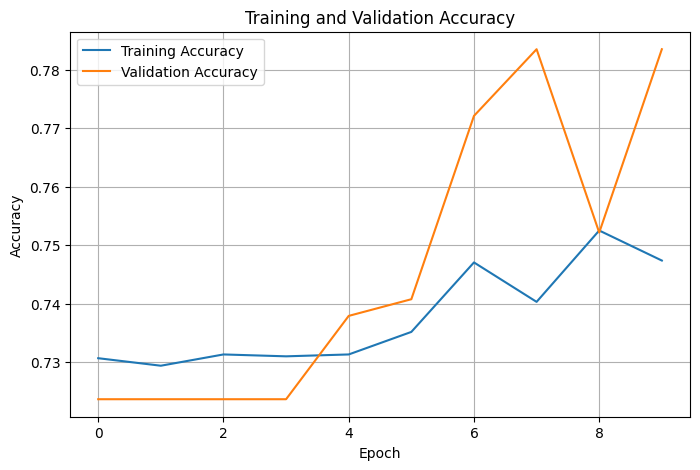

In [42]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

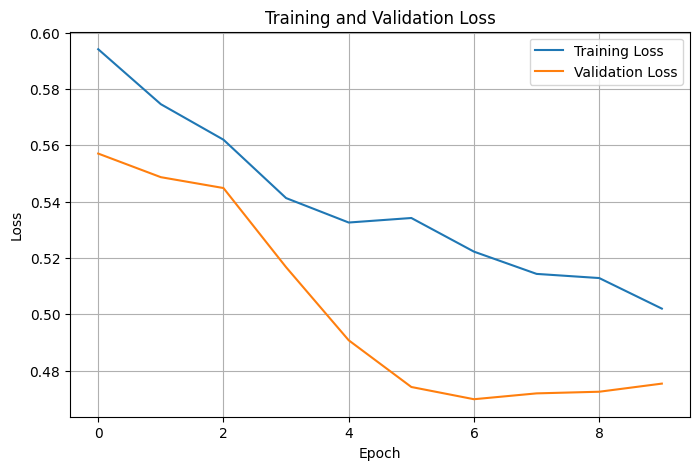

In [43]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [44]:
test_loss, test_accuracy = model.evaluate(
    test_generator
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7716 - loss: 0.4679


In [45]:
print(
    "Test Loss:",
    round(
        test_loss,
        4
    )
)

print(
    "Test Accuracy:",
    round(
        test_accuracy,
        4
    )
)

print(
    "Test Accuracy Percentage:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

Test Loss: 0.4679
Test Accuracy: 0.7716
Test Accuracy Percentage: 77.16 %


In [46]:
test_generator.reset()

In [47]:
predictions = model.predict(
    test_generator
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


In [48]:
predicted_classes = (
    predictions >= 0.5
).astype(int).flatten()

In [49]:
actual_classes = (
    test_generator.classes
)

In [50]:
print(
    "Actual:",
    actual_classes[:20]
)

print(
    "Predicted:",
    predicted_classes[:20]
)

Actual: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Predicted: [1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1]


In [51]:
print(
    classification_report(

        actual_classes,

        predicted_classes,

        target_names=[
            "Fruit",
            "Vegetable"
        ]
    )
)

              precision    recall  f1-score   support

       Fruit       0.84      0.21      0.34        99
   Vegetable       0.77      0.98      0.86       260

    accuracy                           0.77       359
   macro avg       0.80      0.60      0.60       359
weighted avg       0.79      0.77      0.72       359



In [52]:
cm = confusion_matrix(
    actual_classes,
    predicted_classes
)

print(cm)

[[ 21  78]
 [  4 256]]


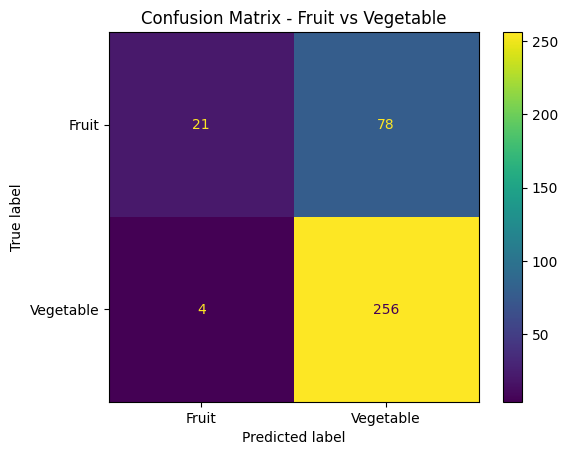

In [53]:
disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Fruit",
        "Vegetable"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Fruit vs Vegetable"
)

plt.show()

In [54]:
correct_predictions = np.sum(
    actual_classes ==
    predicted_classes
)

total_predictions = len(
    actual_classes
)

incorrect_predictions = (
    total_predictions -
    correct_predictions
)

print(
    "Correct Predictions:",
    correct_predictions
)

print(
    "Incorrect Predictions:",
    incorrect_predictions
)

print(
    "Total Predictions:",
    total_predictions
)

Correct Predictions: 277
Incorrect Predictions: 82
Total Predictions: 359


In [55]:
test_generator.reset()

images, labels = next(
    test_generator
)

pred_probs = model.predict(
    images
)

pred_labels = (
    pred_probs >= 0.5
).astype(int).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


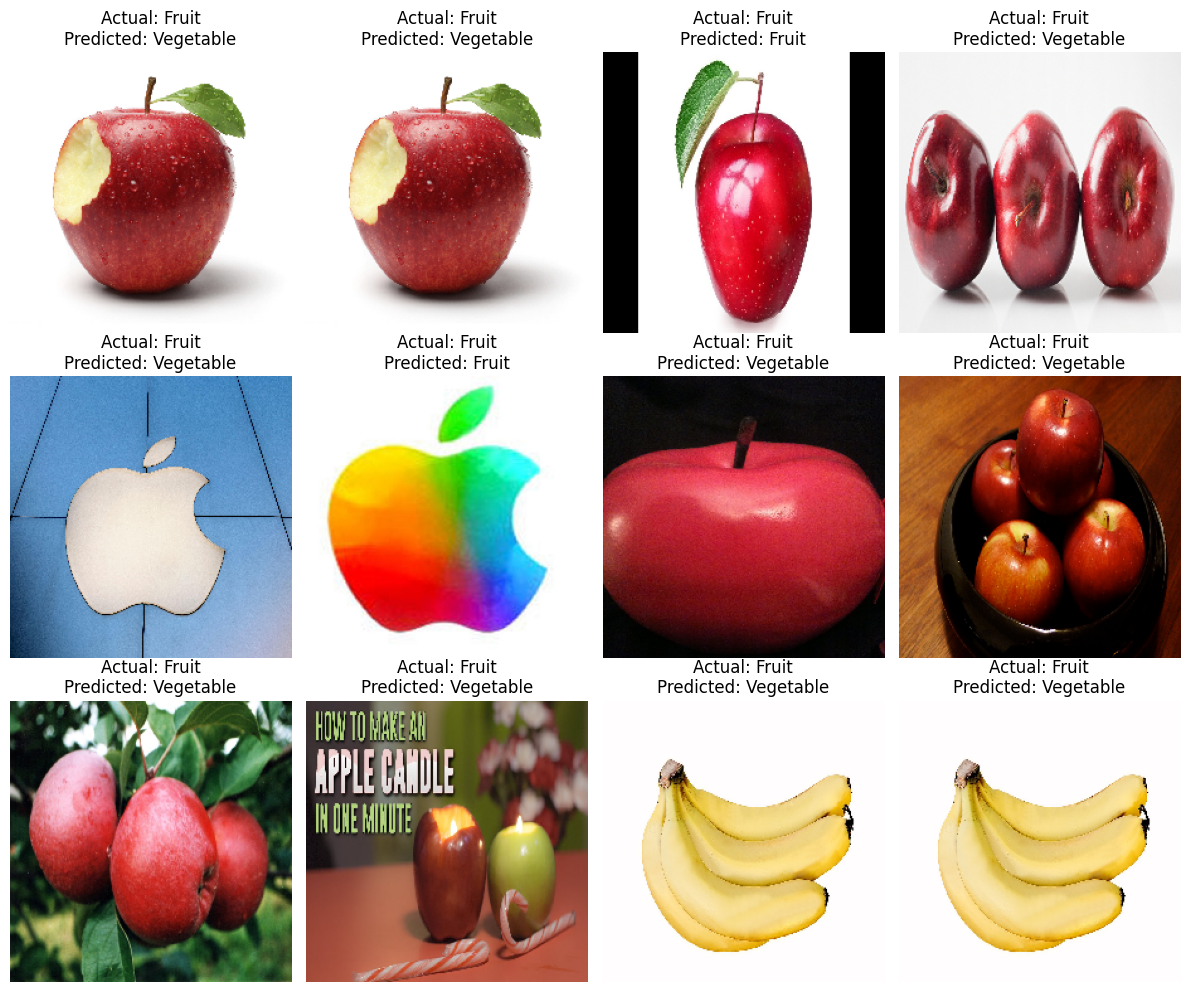

In [56]:
plt.figure(
    figsize=(12, 10)
)

class_names_binary = {
    0: "Fruit",
    1: "Vegetable"
}

for i in range(
    min(12, len(images))
):

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        images[i]
    )

    actual = class_names_binary[
        int(labels[i])
    ]

    predicted = class_names_binary[
        int(pred_labels[i])
    ]

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [57]:
fruit_test_folder = os.path.join(
    binary_base,
    "test",
    "fruit"
)

sample_image = os.path.join(
    fruit_test_folder,
    os.listdir(
        fruit_test_folder
    )[0]
)

print(sample_image)

/content/binary_dataset/test/fruit/pear_Image_6.jpg


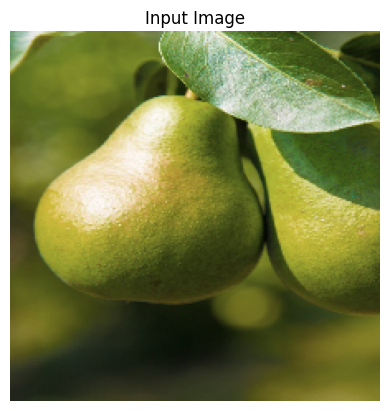

In [58]:
img = load_img(
    sample_image,
    target_size=(
        IMG_SIZE,
        IMG_SIZE
    )
)

plt.imshow(img)

plt.title(
    "Input Image"
)

plt.axis("off")

plt.show()

In [59]:
img_array = img_to_array(
    img
)

img_array = (
    img_array /
    255.0
)

img_array = np.expand_dims(
    img_array,
    axis=0
)

print(
    img_array.shape
)

(1, 224, 224, 3)


In [60]:
prediction = model.predict(
    img_array
)[0][0]

print(
    "Prediction probability:",
    prediction
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Prediction probability: 0.71403486


In [61]:
if prediction < 0.5:

    print(
        "Prediction: FRUIT"
    )

    print(
        "Confidence:",
        round(
            (1 - prediction) * 100,
            2
        ),
        "%"
    )

else:

    print(
        "Prediction: VEGETABLE"
    )

    print(
        "Confidence:",
        round(
            prediction * 100,
            2
        ),
        "%"
    )

Prediction: VEGETABLE
Confidence: 71.4 %


In [63]:
def predict_food_image(
    image_path
):

    img = load_img(
        image_path,
        target_size=(
            IMG_SIZE,
            IMG_SIZE
        )
    )

    plt.imshow(img)

    plt.axis("off")

    plt.show()

    img_array = img_to_array(
        img
    )

    img_array = (
        img_array /
        255.0
    )

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )[0][0]

    if prediction < 0.5:

        result = "FRUIT"

        confidence = (
            1 - prediction
        ) * 100

    else:

        result = "VEGETABLE"

        confidence = (
            prediction * 100
        )

    print(
        "Prediction:",
        result
    )

    print(
        "Confidence:",
        round(
            confidence,
            2
        ),
        "%"
    )

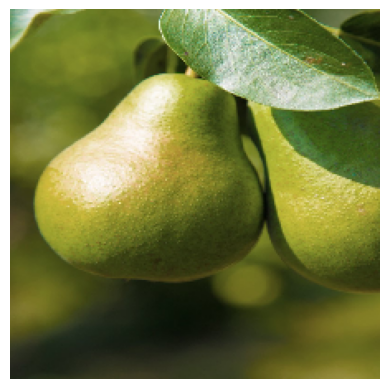

Prediction: VEGETABLE
Confidence: 71.4 %


In [64]:
predict_food_image(
    sample_image
)

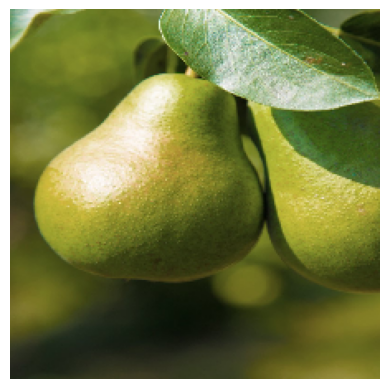

Prediction: VEGETABLE
Confidence: 71.4 %


In [66]:
predict_food_image(
    sample_image
)

In [74]:
from google.colab import files

uploaded = files.upload()

Saving chilli.jfif to chilli.jfif


Uploaded image: chilli.jfif


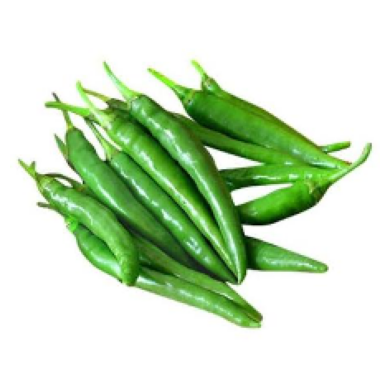

Prediction: VEGETABLE
Confidence: 99.68 %


In [75]:
uploaded_image_name = list(uploaded.keys())[0]

print("Uploaded image:", uploaded_image_name)

predict_food_image(uploaded_image_name)

Uploaded image: chilli.jfif


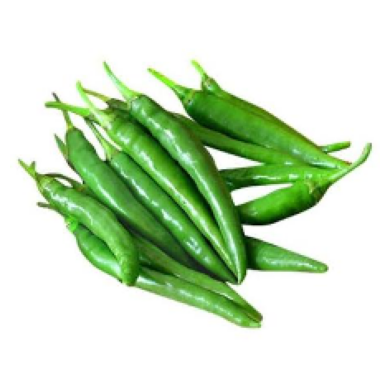

Prediction: VEGETABLE
Confidence: 99.68 %
Model saved successfully.
MODEL SUMMARY
Problem Type: Binary Image Classification
Classes: Fruit and Vegetable
Image Size: 224 x 224
Model: Convolutional Neural Network
Optimizer: Adam
Loss Function: Binary Crossentropy
Output Activation: Sigmoid
Test Accuracy: 77.16 %


In [76]:
uploaded_image_name = list(
    uploaded.keys()
)[0]

print(
    "Uploaded image:",
    uploaded_image_name
)
predict_food_image(
    uploaded_image_name
)
model.save(
    "/content/fruit_vegetable_classifier.keras"
)

print(
    "Model saved successfully."
)
print(
    "MODEL SUMMARY"
)

print(
    "Problem Type: Binary Image Classification"
)

print(
    "Classes: Fruit and Vegetable"
)

print(
    "Image Size: 224 x 224"
)

print(
    "Model: Convolutional Neural Network"
)

print(
    "Optimizer: Adam"
)

print(
    "Loss Function: Binary Crossentropy"
)

print(
    "Output Activation: Sigmoid"
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)